# Chapter 3: Dimensionality Reduction Techniques

## 📋 Summary

High-dimensional datasets suffer from the **curse of dimensionality** — as features increase, data becomes increasingly sparse, distances lose meaning, and models become prone to overfitting. Dimensionality reduction addresses this by projecting data into a lower-dimensional space while retaining the most important structure.

This chapter covers three major techniques: **PCA** (Principal Component Analysis) for linear unsupervised reduction, **LDA** (Linear Discriminant Analysis) for supervised reduction that maximizes class separability, and **t-SNE** for non-linear visualization of high-dimensional data.

The chapter includes practical guidance on when to use each technique, how dimensionality reduction impacts model performance, and hands-on exercises combining reduction with classification models.

---

## 🧠 Theoretical Explanation

### PCA (Principal Component Analysis)
PCA finds the directions (principal components) of maximum variance in the data. Mathematically:
1. Center the data: subtract the mean
2. Compute the covariance matrix: `Σ = (1/n) X^T X`
3. Compute eigenvectors and eigenvalues of `Σ`
4. Sort eigenvectors by descending eigenvalue — these are the principal components
5. Project data onto the top k components

PCA is **unsupervised** — it ignores class labels. The `explained_variance_ratio_` tells you how much variance each component captures.

### LDA (Linear Discriminant Analysis)
LDA is **supervised** — it uses class labels to find the projection that maximizes the ratio of between-class variance to within-class variance. It maximizes class separability, making it ideal as a preprocessing step before classification. LDA can produce at most `C-1` components (where C = number of classes).

### t-SNE (t-distributed Stochastic Neighbor Embedding)
t-SNE is a **non-linear** technique primarily used for visualization. It models each high-dimensional point as a Gaussian distribution and maps to 2D/3D using a Student's t-distribution. t-SNE:
- Preserves local structure (nearby points stay nearby)
- Does NOT preserve global structure (cluster distances are not meaningful)
- Is stochastic (results vary across runs)
- Should NOT be used as a preprocessing step for ML models

### Choosing a Technique
| Technique | Supervised? | Preserves | Use Case |
|-----------|-------------|-----------|----------|
| PCA | No | Global variance | Noise reduction, speed up training |
| LDA | Yes | Class separability | Before classification |
| t-SNE | No | Local structure | Visualization only |


## 3.1 PCA — Principal Component Analysis

In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

# Load digits dataset (64 features)
digits = load_digits()
X, y = digits.data, digits.target

# Scale first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'Original shape: {X.shape}')
print(f'After PCA: {X_pca.shape}')
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.3f}')

Original shape: (1797, 64)
After PCA: (1797, 2)
Explained variance ratio: [0.12033916 0.09561054]
Total variance explained: 0.216


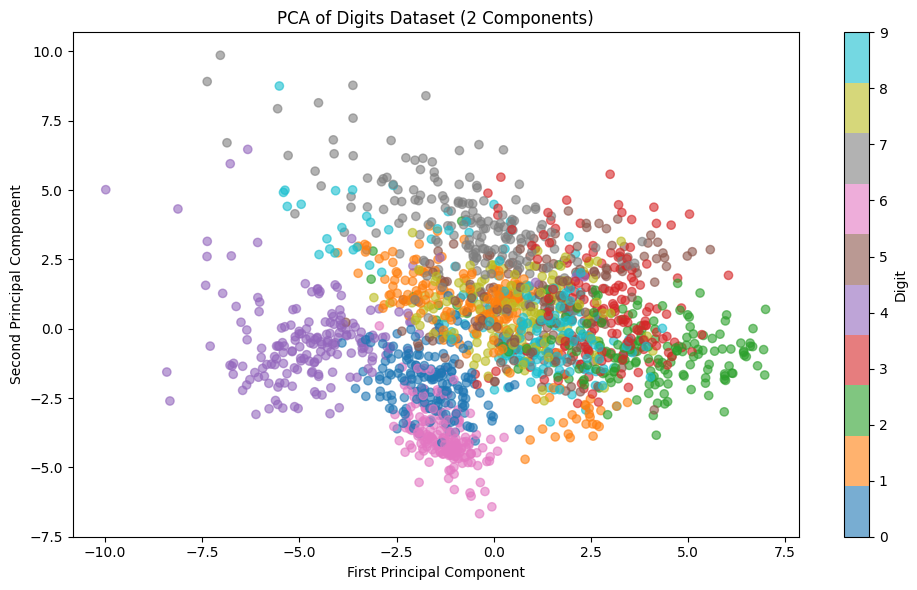

In [2]:
# Visualize PCA
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Digit')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA of Digits Dataset (2 Components)')
plt.tight_layout()
plt.show()

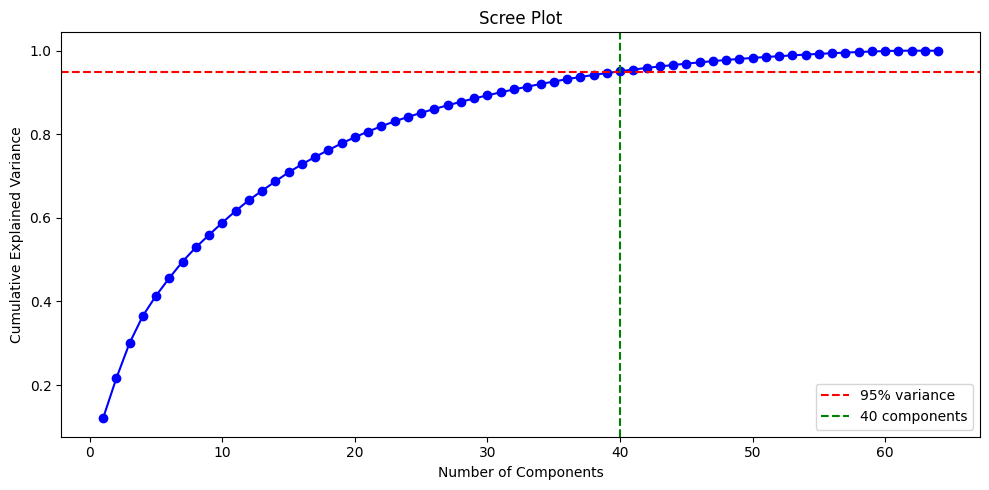

Components needed for 95% variance: 40


In [3]:
# Scree plot - how many components to keep?
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Components needed for 95% variance: {n_components_95}')

## 3.2 LDA — Linear Discriminant Analysis

Original shape: (150, 4)
After LDA: (150, 2)
Explained variance ratio: [0.9912126 0.0087874]


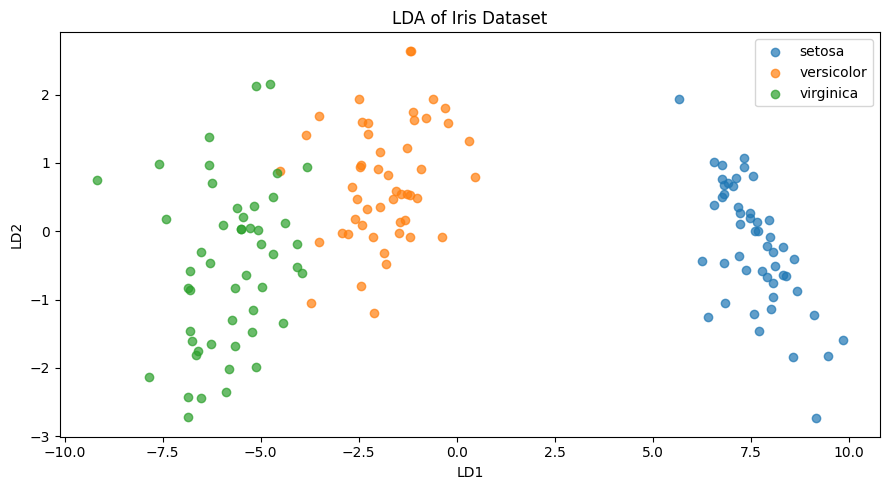

In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Iris has 3 classes -> max 2 LDA components
iris = load_iris()
X, y = iris.data, iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)  # Note: y is passed to fit()

print(f'Original shape: {X.shape}')
print(f'After LDA: {X_lda.shape}')
print(f'Explained variance ratio: {lda.explained_variance_ratio_}')

plt.figure(figsize=(9, 5))
for i, name in enumerate(iris.target_names):
    plt.scatter(X_lda[y==i, 0], X_lda[y==i, 1], label=name, alpha=0.7)
plt.xlabel('LD1'); plt.ylabel('LD2')
plt.title('LDA of Iris Dataset')
plt.legend(); plt.tight_layout(); plt.show()

In [5]:
# Compare: PCA vs LDA as preprocessing for Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

iris = load_iris()
X, y = iris.data, iris.target

# PCA pipeline
pca_pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=2)), ('clf', LogisticRegression(max_iter=200))])
# LDA pipeline
lda_pipe = Pipeline([('scaler', StandardScaler()), ('lda', LinearDiscriminantAnalysis(n_components=2)), ('clf', LogisticRegression(max_iter=200))])
# No reduction
base_pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=200))])

for name, pipe in [('No reduction', base_pipe), ('PCA', pca_pipe), ('LDA', lda_pipe)]:
    score = cross_val_score(pipe, X, y, cv=5).mean()
    print(f'{name}: {score:.3f}')

No reduction: 0.960
PCA: 0.913


LDA: 0.980


## 3.3 t-SNE — Visualization of High-Dimensional Data

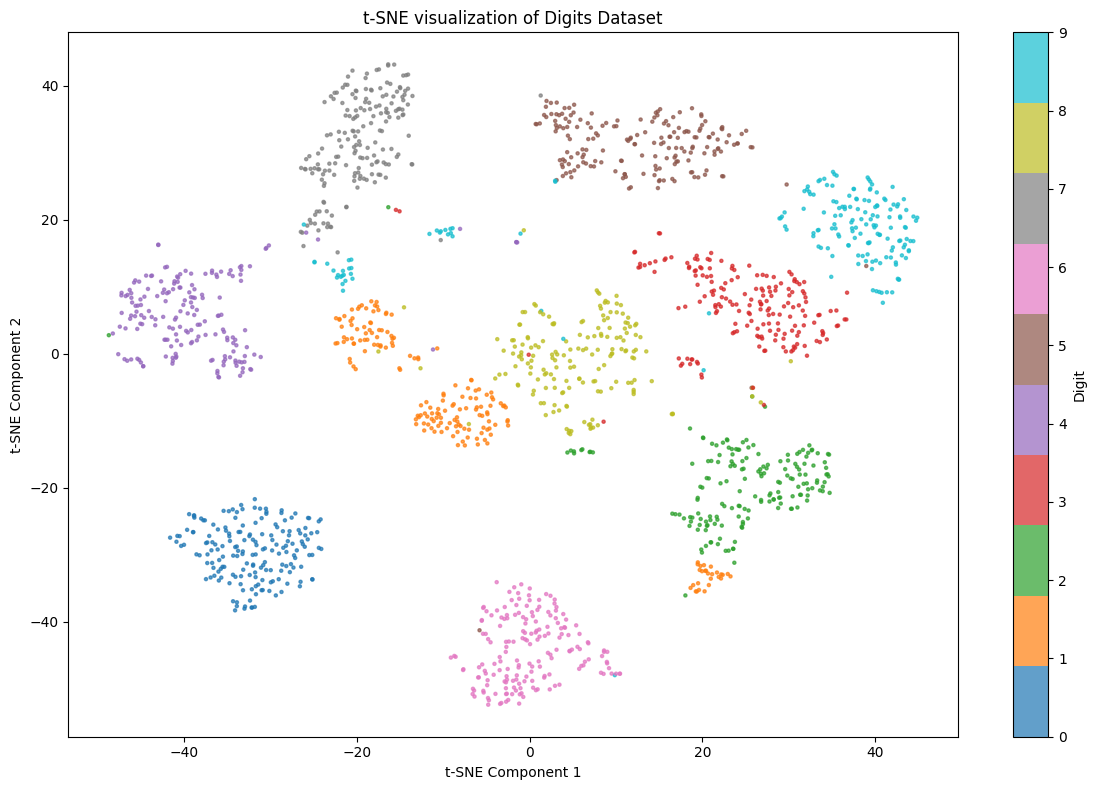

In [6]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()
X, y = digits.data, digits.target

# PCA first to speed up t-SNE
pca_50 = PCA(n_components=50)
X_pca = pca_50.fit_transform(StandardScaler().fit_transform(X))

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7, s=5)
plt.colorbar(scatter, label='Digit')
plt.title('t-SNE visualization of Digits Dataset')
plt.xlabel('t-SNE Component 1'); plt.ylabel('t-SNE Component 2')
plt.tight_layout(); plt.show()

## 🔑 Key Takeaways

- **PCA** reduces dimensions by finding directions of maximum variance. Use it to remove noise, speed up training, and avoid overfitting.
- **LDA** maximizes class separability — it's supervised and more powerful than PCA as a preprocessing step for classification.
- **t-SNE** is for visualization only. Do not use it as a preprocessing step for ML models.
- Always **scale your data** before applying dimensionality reduction.
- Use a **scree plot** to determine how many PCA components to keep (typically 95% variance threshold).
- Dimensionality reduction can improve or hurt model performance depending on the dataset — always compare with and without.
